<a href="https://colab.research.google.com/github/INSVikrant54/Neural-Network/blob/main/NeuralNetwork_(6).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!pip install nnfs

In [19]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data

nnfs.init()

class Layer_Dense:
  def __init__(self, n_inputs, n_neurons):
    self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)  #multiplying by 0.10 to get values betwwen -1 and 1
    self.biases = np.zeros((1, n_neurons))    # 1- is the shape of bias and also no need for Transpose as np.np.random.randn handles that
  def forward(self, inputs):
    self.output = np.dot(inputs, self.weights) + self.biases

#Rectified Linear(ReLU) OBJECT
class Activation_ReLU:
  def forward(self, inputs):
    self.output = np.maximum(0, inputs)

class Activation_SoftMax:
  def forward(self, inputs):
    exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
    probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
    self.output = probabilities



X, y = spiral_data(samples=100, classes=3)

dense1 = Layer_Dense(2 ,3)   #(2- no. of features per input/sample(here spirial dataset has x and y axis), 3- no of neurons we nedd(LITERALLY CAN BE ANY VALUE))
activation1 = Activation_ReLU()

dense2 = Layer_Dense(3, 3)
activation2 = Activation_SoftMax()

dense1.forward(X)
activation1.forward(dense1.output)  #We are inputing the calulatedd valuess in ReLU to make -ve values to 0 and +ve values remains same

dense2.forward(activation1.output)  #passing the ReLU values to SoftMax Fn
activation2.forward(dense2.output)

print(activation2.output[:5])  #shows only 5 batches



#(in Next File added)
#loss function : how much wrong or right are the values obtained or how much wrong is the MODEL


[[0.33333334 0.33333334 0.33333334]
 [0.33331734 0.3333183  0.33336434]
 [0.3332888  0.33329153 0.33341965]
 [0.33325943 0.33326396 0.33347666]
 [0.33323312 0.33323926 0.33352762]]


# Overcoming OVERFLOW ERROR



*   As we are doing exponential , we can encounter overflow error with large values

*   So, we need to subtract the values before the exponential steps with Max vale present.

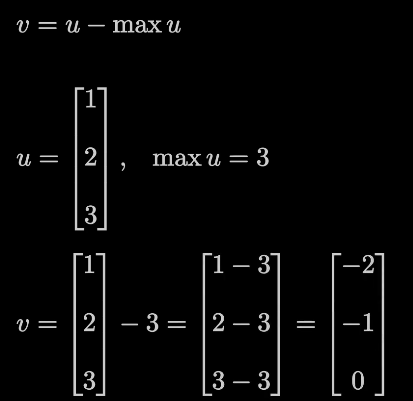

SUBTRACTING causes no effects, and even limits the values betwwen 0 and 1

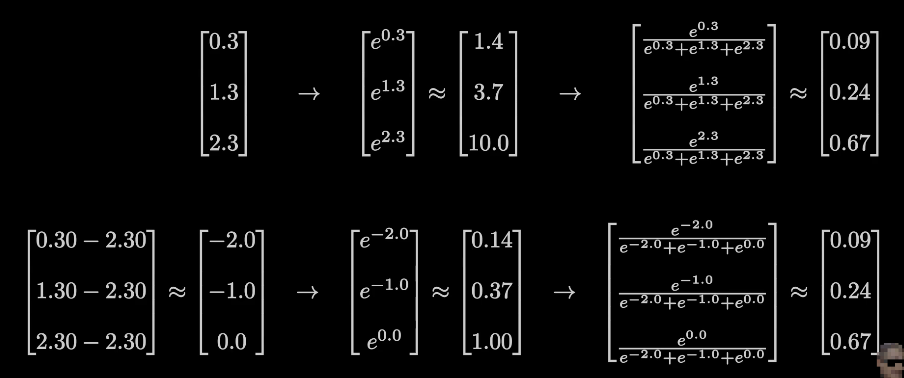

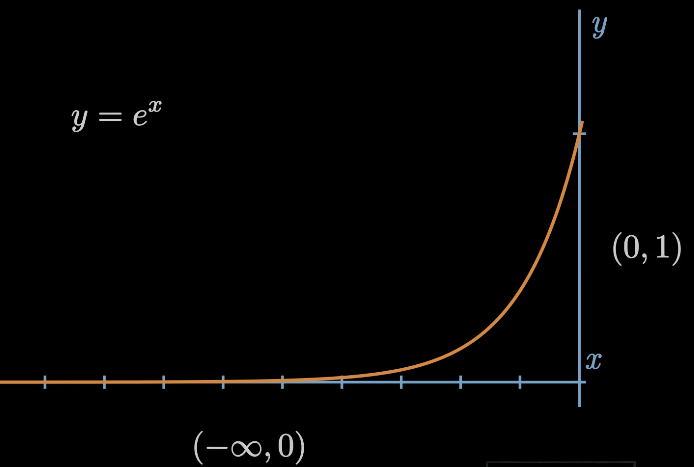

THUS, Overall resulting in no more than protecting ourself from overflow ERROR



1.   #axis=None : Convert(add) all values to 1
2. #axis = 0 : Convert(add) all values as columns wise
3. #axis = 1 : Convert(add) all values as row wise (This is need for batch)

4. #keepdims = True : Retains original diminsions(shape or structure)



In [9]:
import numpy as np

layer_outputs = [[4.8, 1.21, 2.385],  # NOW Handling BATCH of inputs
                 [8.9, -1.81, 0.2],
                 [1.41, 1.051, 0.026]]

exp_values = np.exp(layer_outputs)
norm_values = exp_values / np.sum(exp_values, axis=1, keepdims=True)

print(norm_values)

[[8.95282664e-01 2.47083068e-02 8.00090293e-02]
 [9.99811129e-01 2.23163963e-05 1.66554348e-04]
 [5.13097164e-01 3.58333899e-01 1.28568936e-01]]


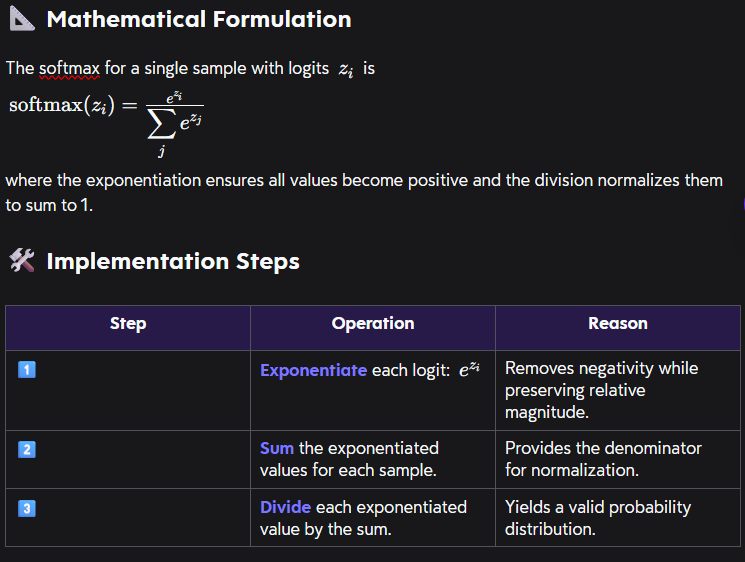

SOFTMAX Fn (Exponential + Normalize )using numpy

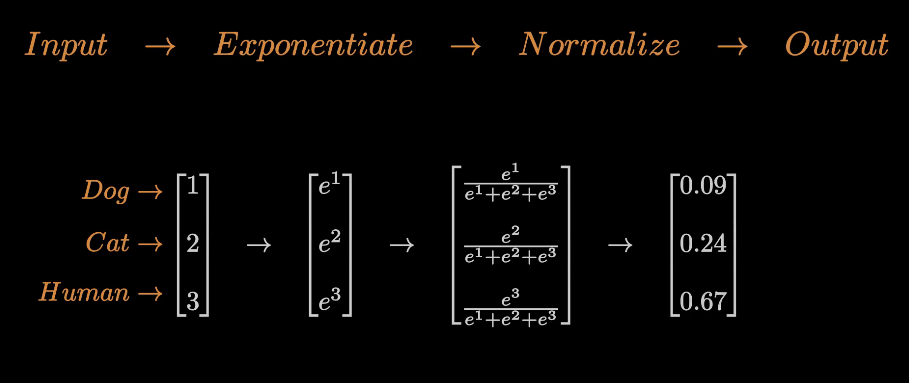


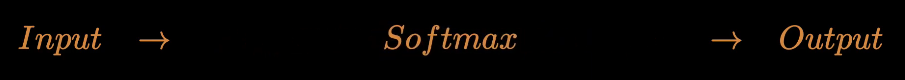


In [7]:
import numpy as np

layer_outputs = [4.8, 1.21, 2.385]

exp_values = np.exp(layer_outputs)

norm_values = exp_values/np.sum(exp_values)

print(norm_values)
print(sum(norm_values))

[0.89528266 0.02470831 0.08000903]
0.9999999999999999


NORMALIZATION JUST scales the big and -ve values and thus retaining their original values(importance)

The Values obtain are just Probability distribution which when sumed can get valye 1.

In [2]:
#RAW EXPONENTIAL FUNCTION + NORMALIZATION = SOFTMAX fn
import math

layer_outputs = [4.8, 1.21, 2.385]
#E = 2.71828182846 (Euler's Number)
E = math.e

exp_values = []

for output in layer_outputs:
    exp_values.append(E**output)

print(exp_values) #Exponential values of the input

norm_base = sum(exp_values)
norm_values = []

for values in exp_values:
    norm_values.append(values/norm_base)

print(norm_values)     #NORMALIZED VALUES
print(sum(norm_values))

[121.51041751873483, 3.353484652549023, 10.859062664920513]
[0.8952826639572619, 0.024708306782099374, 0.0800090292606387]
0.9999999999999999


**EXPONENTIAL FN JUST MAKES SURE that no -ve values are present **

In [1]:
#RAW EXPONENTIAL FUNCTION
import math

layer_outputs = [4.8, 1.21, 2.385]
#E = 2.71828182846 (Euler's Number)
E = math.e

exp_values = []

for output in layer_outputs:
    exp_values.append(E**output)

print(exp_values) #Exponential values of the input

[121.51041751873483, 3.353484652549023, 10.859062664920513]


# SOFTMAX ACTIVATION FUNCTION



*   Softmax is an activation function used in the output layer of classification neural networks. It converts raw output scores (logits) into a probability distribution over classes.



*   To Train a model our first step is to know how wrong a model is , so in oredr to know that we use softmax fn to know the probability


#❓ Why Not Use ReLU or Linear Activations for the Output Layer?



1. **ReLU is exclusive per neuron;** it does not provide a relative comparison between neurons and its output can be zero for negative inputs, losing information about the magnitude of negatives.



2. **Linear / identity activations leave negative values unchanged**, making it unclear how to interpret them as probabilities and how to back‑propagate gradients meaningfully.
